# Generation of graph data from existing graphs

In [2]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

## Creating a graph from the fracture network 

In [52]:
# Read geodataframe with geopandas
name = 'tcfr'
gdf = gpd.read_file (f'data/australia/shapefile/{name}.shp')

#australia = en_north, en_south, hhs, inv, tcfr
#aland_finland = Getaberget_20m_8, Flato_20m_1, Getaberget_20m_1, Getaberget_20m_2_1, Getaberget_20m_2_2, Getaberget_20m_3_1, Getaberget_20m_4_1
#apodi_nebrazil = apodi2, apodi3, apodi4, dix-sept1, simplified17
#brejoes_brazil = Brejoes_Fractures, (Station_Mid1, Station_Mid2, Station_Mid3, North, South1)
#bristol_uk = Area1, Area2, Area3, Area4, Area5
#coastal_ireland = Coastal_Bedrock_Geology_snp
#forsmark_esweden = fractures_projected_snp
#min_mountains_usa = Mineral_mtns
#off_sebrazil = off_sebrazil
#parmelan_france = Parmelan ---verify geometry--
#patterns = star, hexagonon, diamond, square, braided, brick, pavement, polygonal, stochastic, out_star, hexagonon, out_diamond, out_square, out_braided, out_brick, out_pavement, out_polygonal, out_stochastic
#patterns_bristol = Manual_NE1, Manual_NE2, Manual_SW1, Manual_SW2, Manual_SW3
#salta_nwargentina = 0
#synthetic = abutments, conjugate, splays, voronoi
#tsanfleuron_swissalps = tsan_fractures, frac_graph_1000, tsan_D

In [53]:
# Create graph from geodataframe
G = nx.Graph()
coord_to_label = {}
precision = 5 #decimals

for index, row in gdf.iterrows():
    line = row['geometry']
    
    if line is not None:
        coordinates = [(round(coord[0], precision), round(coord[1], precision)) for coord in line.coords]

        for i, coord in enumerate(coordinates):
            if coord not in coord_to_label:
                label_index = len(coord_to_label)
                coord_to_label[coord] = label_index
                G.add_node(label_index, pos=coord)

        edges = [(coord_to_label[coordinates[i]], coord_to_label[coordinates[i + 1]]) for i in range(len(coordinates) - 1)]
        G.add_edges_from(edges)    

In [54]:
# Remove selfloops
self_loops = list(nx.selfloop_edges(G))
G.remove_edges_from(self_loops)

In [55]:
# Generate a position dictionary
pos = nx.get_node_attributes(G, 'pos')

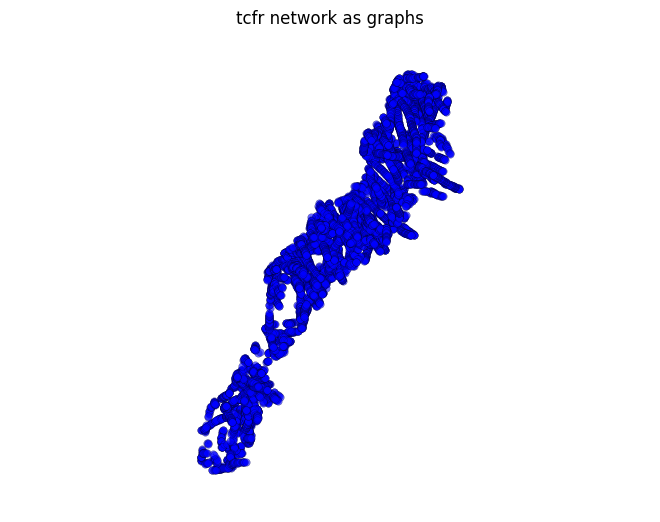

In [56]:
# Plot the fracture network as graphs
kwds = {
    'with_labels': False, 
    'node_shape': 'o',         # node symbol
    'node_color': 'blue',      # node color
    'edgecolors': 'black',     # node border color
    'node_size': 30,            # node size
    'linewidths': 0.2,         # node border width
    'edge_color': 'black',     # edge color
    'width': 1,                # edge width
    'font_size': 8,            # font size
    'font_color': 'black',      # font color
    'alpha': 0.6 ,              # transparency
}

pos = nx.get_node_attributes(G, 'pos')

nx.draw(G, pos=pos, **kwds)
plt.title(f'{name} network as graphs')
plt.axis('equal')

#plt.savefig(f'{name}.png', transparent=True, dpi=300)
    
plt.show()

### Read picke as graph G and identify largest connected component to export

In [57]:
# Identify largest 5 connected component
all_components = list(nx.connected_components(G))

# Sort components by size
components_sorted = sorted(all_components, key=len, reverse=True)
largest_graphs = {}

for i, comp_nodes in enumerate(components_sorted[:5], start=1):
    # Subgraph
    Gc = G.subgraph(comp_nodes).copy()

    # Sort nodes and relabel
    node_list_sorted = sorted(Gc.nodes())
    mapping = {old: new for new, old in enumerate(node_list_sorted)}
    Gc_sorted = nx.relabel_nodes(Gc, mapping, copy=True)

    # Store graph
    largest_graphs[f'{i}'] = Gc_sorted

    # Export graph as pickle
    pickle.dump(Gc_sorted, open(f'data/{name}_{i}.pickle', 'wb'))

In [58]:
# Read fracture network as graph (pickle)
Gp = pickle.load(open(f'data/{name}_4.pickle', 'rb'))

(385306.27273905, 385345.46995095, 5719953.8871957, 5719995.198604301)

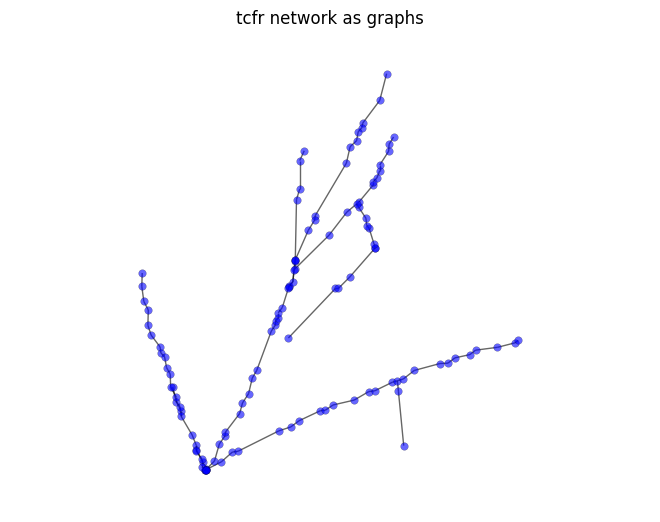

In [59]:
# Plot the fracture network as graphs
kwds = {
    'with_labels': False, 
    'node_shape': 'o',         # node symbol
    'node_color': 'blue',      # node color
    'edgecolors': 'black',     # node border color
    'node_size': 30,            # node size
    'linewidths': 0.2,         # node border width
    'edge_color': 'black',     # edge color
    'width': 1,                # edge width
    'font_size': 8,            # font size
    'font_color': 'black',      # font color
    'alpha': 0.6 ,              # transparency
}

pos = nx.get_node_attributes(Gp, 'pos')

nx.draw(Gp, pos=pos, **kwds)
plt.title(f'{name} network as graphs')
plt.axis('equal')